# StyleSync — Improved Classifier (v2)

Builds on `model_training.ipynb`. Same 5-class category task, same 20 epochs on GPU, same balanced dataset (already downloaded locally via `scripts/download_balanced_images.py`).

**Improvements over baseline:**
1. **Data augmentation** on the training set (random crop, flip, rotation, color jitter) — wardrobe photos vary in lighting/angle, so this should help generalization.
2. **Unfreeze `layer4`** of ResNet50 instead of training only the FC head — lets the model adapt high-level features to clothing.
3. **AdamW + weight decay** (L2 regularization) to fight overfitting.
4. **CosineAnnealingLR scheduler** — smooth LR decay across the 20 epochs.
5. **Differential learning rates** — smaller LR for the unfrozen backbone, larger LR for the new FC head.
6. **Best-checkpoint tracking** — save the model from the epoch with the highest validation accuracy, not the last one.

In [1]:
import sys
import os
from pathlib import Path
from io import BytesIO
import copy

sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SUBCATEGORY_TO_LABEL = {
    "Tops":       0,
    "Bottomwear": 1,
    "Shoes":      2,
    "Dress":      3,
    "Outerwear":  4,
}
LABEL_TO_SUBCATEGORY = {v: k for k, v in SUBCATEGORY_TO_LABEL.items()}
CLASS_NAMES = [LABEL_TO_SUBCATEGORY[i] for i in range(len(SUBCATEGORY_TO_LABEL))]
NUM_CLASSES = len(SUBCATEGORY_TO_LABEL)

### Transforms — separate pipelines for train vs val

Augmentation only runs during training. Validation gets a deterministic resize + normalize so metrics stay comparable to the baseline.

In [3]:
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [4]:
def download_image(url):
    try:
        response = requests.get(url, timeout=2)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return None


class WardrobeDataset(Dataset):
    def __init__(self, df, transform, local_image_dir=None):
        self.df = df.reset_index(drop=True)
        self.local_image_dir = local_image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        image_id     = row["id"]
        url          = row["link"]
        sub_category = row["subCategory"]
        label        = SUBCATEGORY_TO_LABEL.get(sub_category, -1)

        if self.local_image_dir:
            local_path = os.path.join(self.local_image_dir, f"{image_id}.jpg")
            img = Image.open(local_path).convert("RGB") if os.path.exists(local_path) else download_image(url)
        else:
            img = download_image(url)

        if img is None:
            return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE), label

        return self.transform(img), label

### Filter df to images that exist on disk (1 missing image from the download script)

In [ ]:
balanced_df = pd.read_csv("../data/balanced_df.csv")

img_dir = Path("../data/balanced_images")
balanced_df = balanced_df[
    balanced_df["id"].apply(lambda x: (img_dir / f"{x}.jpg").exists())
].reset_index(drop=True)

print(f"Total samples: {len(balanced_df)}")
balanced_df["subCategory"].value_counts()

In [ ]:
train_df, val_df = train_test_split(
    balanced_df, test_size=0.2, random_state=42, stratify=balanced_df["subCategory"]
)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

train_dataset = WardrobeDataset(train_df, transform=train_transform, local_image_dir="../data/balanced_images")
val_dataset   = WardrobeDataset(val_df,   transform=val_transform,   local_image_dir="../data/balanced_images")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

### Model — ResNet50 with `layer4` unfrozen

Baseline trained only the FC head. Here we additionally unfreeze `layer4` (the last residual block) so its high-level features can adapt to clothing. Earlier blocks (`layer1`–`layer3`) stay frozen — they capture general visual features (edges, textures) that transfer well from ImageNet.

In [7]:
model = models.resnet50(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Using device: {device}")
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Using device: mps
Trainable params: 14,974,981 / 23,518,277 (63.7%)


### Optimizer + LR scheduler

- **AdamW** with `weight_decay=1e-4` for L2 regularization.
- **Differential LR**: backbone (`layer4`) gets a smaller LR (`1e-4`) so we don't wreck pretrained features; the new FC head gets the standard `1e-3`.
- **CosineAnnealingLR** smoothly decays both LRs to near-zero over 20 epochs.

In [8]:
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ],
    weight_decay=1e-4,
)

scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

### Training loop

Same 20 epochs as the baseline. Each epoch we step the scheduler and track the best validation accuracy so we can save the strongest checkpoint.

In [9]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
best_state   = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss / len(train_loader))
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = copy.deepcopy(model.state_dict())
        marker = "  *best*"
    else:
        marker = ""

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f} | "
        f"LR(head): {current_lr:.2e}{marker}"
    )

    scheduler.step()

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.5114 | Train Acc: 0.8045 | Val Loss: 0.1885 | Val Acc: 0.9247 | LR(head): 1.00e-04  *best*
Epoch 02/20 | Train Loss: 0.2335 | Train Acc: 0.9211 | Val Loss: 0.2573 | Val Acc: 0.9032 | LR(head): 9.94e-05
Epoch 03/20 | Train Loss: 0.1637 | Train Acc: 0.9435 | Val Loss: 0.1972 | Val Acc: 0.9355 | LR(head): 9.76e-05  *best*
Epoch 04/20 | Train Loss: 0.0827 | Train Acc: 0.9668 | Val Loss: 0.1659 | Val Acc: 0.9534 | LR(head): 9.46e-05  *best*
Epoch 05/20 | Train Loss: 0.0974 | Train Acc: 0.9686 | Val Loss: 0.1401 | Val Acc: 0.9462 | LR(head): 9.05e-05
Epoch 06/20 | Train Loss: 0.0661 | Train Acc: 0.9776 | Val Loss: 0.1695 | Val Acc: 0.9462 | LR(head): 8.54e-05
Epoch 07/20 | Train Loss: 0.0543 | Train Acc: 0.9821 | Val Loss: 0.1889 | Val Acc: 0.9427 | LR(head): 7.94e-05
Epoch 08/20 | Train Loss: 0.0445 | Train Acc: 0.9848 | Val Loss: 0.1697 | Val Acc: 0.9570 | LR(head): 7.27e-05  *best*
Epoch 09/20 | Train Loss: 0.0567 | Train Acc: 0.9812 | Val Loss: 0.1778 | Val Ac

### Training curves

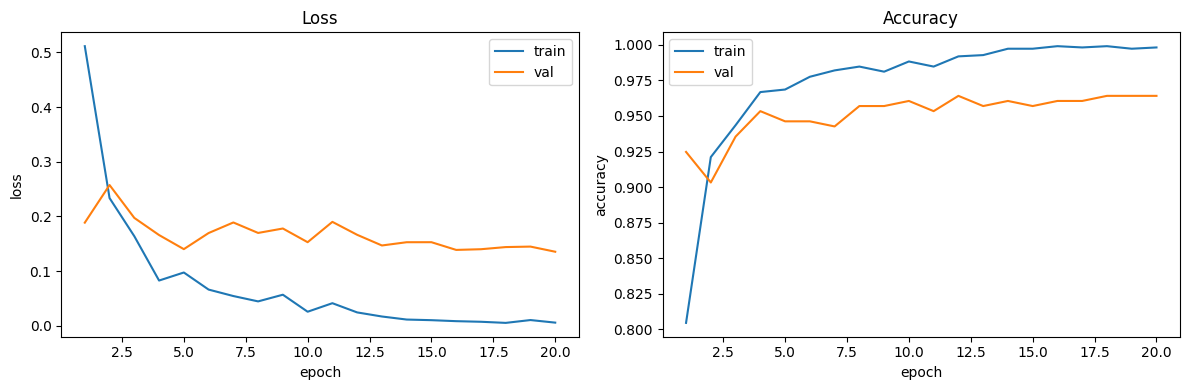

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="train")
axes[0].plot(epochs_x, history["val_loss"],   label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_x, history["train_acc"], label="train")
axes[1].plot(epochs_x, history["val_acc"],   label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout(); plt.show()

### Save the best checkpoint

In [11]:
os.makedirs("../models", exist_ok=True)
out_path = "../models/resnet50_stylesync_v2.pt"
torch.save(best_state, out_path)
print(f"Best model (val_acc={best_val_acc:.4f}) saved to {out_path}")

Best model (val_acc=0.9642) saved to ../models/resnet50_stylesync_v2.pt


### Evaluation — confusion matrix + per-class report

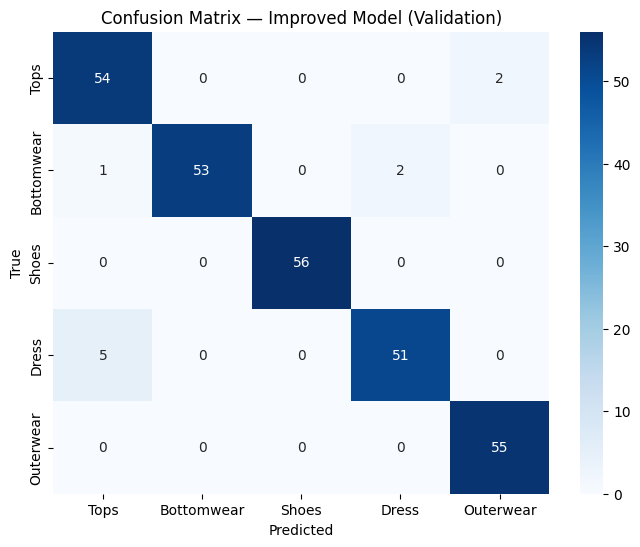

              precision    recall  f1-score   support

        Tops       0.90      0.96      0.93        56
  Bottomwear       1.00      0.95      0.97        56
       Shoes       1.00      1.00      1.00        56
       Dress       0.96      0.91      0.94        56
   Outerwear       0.96      1.00      0.98        55

    accuracy                           0.96       279
   macro avg       0.97      0.96      0.96       279
weighted avg       0.97      0.96      0.96       279



In [12]:
model.load_state_dict(torch.load(out_path, map_location=device))
model = model.to(device)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        preds  = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Improved Model (Validation)")
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### Where this fits in the pipeline

Per the project plan, this model handles the **clothing category** part of the CV layer (top / bottom / dress / outerwear / shoes). Color and occasion/genre are intentionally *not* part of this model:

- **Color** → handled separately via k-means on pixels (CV engineer B's piece).
- **Occasion / style genre** → handled by the rule-based outfit engine using `category + color + subcategory` lookups (recommendation engineer's piece).

Keeping this classifier focused on category gives the rest of the pipeline a clean, reliable signal to build on.